# Atelier Préparation de Données Images 

Contexte 
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître 
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des 
déchets. 
Le modèle devra classer chaque image dans l'une des catégories suivantes : 
 cardboard : cartons ondulés, cartons plats, … 
 plastic : bouteilles, emballages plastiques... 
 paper : feuilles,  journaux... 
 glass : bouteilles et objets en verre... 
 metal : canettes, boîtes métalliques... 
 trash : emballages bonbons, tasses jetables, ... 
Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas 
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images 
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images 
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées. 
L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à 
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning. 

Structure du projet 

In [1]:
import os
import hashlib
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import shutil

# Définition des chemins
BASE_DIR = Path("../data")
RAW_DIR = BASE_DIR / "raw"
CLEANED_DIR = BASE_DIR / "cleaned"
REPORT_DIR = Path("../reports")
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Partie 1 – Exploration du dataset

Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe, 
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa 
taille. 
NB : prendre en charge aussi les fichiers corrompus

In [2]:
data_list = []

for class_name in CLASSES:
    class_path = RAW_DIR / class_name
    for img_path in class_path.glob("*"):
        if img_path.is_file():
            file_size_kb = img_path.stat().st_size / 1024.0
            try:
                with Image.open(img_path) as img:
                    img.verify() # Vérification de l'intégrité
                with Image.open(img_path) as img:
                    img_arr = np.array(img)
                    width, height = img.size
                    mode = img.mode
                    fmt = img.format
                    channels = len(img.getbands())
                    std_dev = np.std(img_arr)
                    is_corrupted = False
            except Exception as e:
                width, height, mode, fmt, channels, std_dev = None, None, None, None, None, None
                is_corrupted = True

            data_list.append({
                'file_path': str(img_path),
                'file_name': img_path.name,
                'class': class_name,
                'format': fmt,
                'mode': mode,
                'width': width,
                'height': height,
                'channels': channels,
                'std_dev': std_dev,
                'size_kb': file_size_kb,
                'is_corrupted': is_corrupted
            })

df_meta = pd.DataFrame(data_list)
print(f"Total d'images recensées : {len(df_meta)}")
df_meta.head()

Total d'images recensées : 1032


,file_path,file_name,class,format,mode,width,height,channels,std_dev,size_kb,is_corrupted
0,..\data\raw\cardboard\cardboard1.jpg,cardboard1.jpg,cardboard,JPEG,RGB,512.0,384.0,3.0,40.586504,16.926758,False
1,..\data\raw\cardboard\cardboard10.jpg,cardboard10.jpg,cardboard,JPEG,RGB,512.0,384.0,3.0,42.577273,21.174805,False
2,..\data\raw\cardboard\cardboard100.jpg,cardboard100.jpg,cardboard,JPEG,RGB,512.0,384.0,3.0,46.121684,14.535156,False
3,..\data\raw\cardboard\cardboard101.jpg,cardboard101.jpg,cardboard,JPEG,RGB,512.0,384.0,3.0,72.264255,13.954102,False
4,..\data\raw\cardboard\cardboard102.jpg,cardboard102.jpg,cardboard,JPEG,RGB,512.0,384.0,3.0,48.389753,17.592773,False


# Partie 2 – Détecter les images corrompues 

Écrire et se servir d’une fonction qui détecte une image corrompue

Explication : Une image est corrompue si la bibliothèque PIL n'arrive pas à la lire ou à décoder son contenu binaire.

In [3]:
def check_corrupted(row):
    return row['is_corrupted']

df_meta['is_corrupted'] = df_meta.apply(check_corrupted, axis=1)
corrupted_files = df_meta[df_meta['is_corrupted']]

print(f"Nombre d'images corrompues : {len(corrupted_files)}")
corrupted_files[['file_name', 'class']]

Nombre d'images corrompues : 6


,file_name,class
147,cardboard83.jpg,cardboard
326,glass74.jpg,glass
446,metal48.jpg,metal
633,paper213.jpg,paper
791,plastic13.jpg,plastic
1004,trash3.jpg,trash


# Partie 3 – Détecter les images vides

Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image 
entièrement blanche ou image dont les pixels présentent très peu de variation.

Explication : Une image vide (tout noir, tout blanc) ou avec très peu de contenu a un écart-type de ses pixels proche de 0 ($\sigma < 5.0$).

In [4]:
def check_empty(row, std_threshold=5.0):
    if row['is_corrupted']:
        return False
    return row['std_dev'] < std_threshold

df_meta['is_empty'] = df_meta.apply(check_empty, axis=1)
empty_files = df_meta[df_meta['is_empty']]

print(f"Nombre d'images quasi vides : {len(empty_files)}")
empty_files[['file_name', 'class', 'std_dev']]

Nombre d'images quasi vides : 2


,file_name,class,std_dev
167,image-blanche-512x384.jpg,cardboard,1.574664
357,image-blanche-512x384.jpg,metal,1.574664


# Partie 4 – Détecter les différences de résolution 

1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus 
fréquentes et le nombre d'images par résolution. 

In [5]:
valid_df = df_meta[~df_meta['is_corrupted']].copy()
valid_df['resolution'] = valid_df['width'].astype(int).astype(str) + "x" + valid_df['height'].astype(int).astype(str)

print("Résolutions les plus fréquentes :")
print(valid_df['resolution'].value_counts().head(10))

min_res = (valid_df['width'].min(), valid_df['height'].min())
max_res = (valid_df['width'].max(), valid_df['height'].max())
print(f"\nRésolution minimale observée : {min_res}")
print(f"Résolution maximale observée : {max_res}")

Résolutions les plus fréquentes :
resolution
512x384    1013
32x32         5
48x32         4
40x40         4
Name: count, dtype: int64

Résolution minimale observée : (32.0, 32.0)
Résolution maximale observée : (512.0, 384.0)


2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifier toutes les images 
ne respectant pas cette contrainte. 

In [6]:
df_meta['is_too_small'] = df_meta.apply(
    lambda r: False if r['is_corrupted'] else (r['width'] < 64 or r['height'] < 64), axis=1
)
small_files = df_meta[df_meta['is_too_small']]
print(f"\nNombre d'images trop petites (<64x64) : {len(small_files)}")


Nombre d'images trop petites (<64x64) : 13


# Partie 5 – Détecter les différents canaux 

Déterminer le nombre d'images selon leur nombre de canaux. 


Explication : Nous comptons le nombre d'images selon leurs canaux (ex: 1 canal pour L/grayscale, 3 pour RGB, 4 pour RGBA).

In [7]:
channel_counts = df_meta[~df_meta['is_corrupted']]['channels'].value_counts()
print("Répartition selon le nombre de canaux :")
print(channel_counts)

df_meta['is_grayscale'] = df_meta['channels'] == 1
df_meta['is_rgba'] = df_meta['channels'] == 4

Répartition selon le nombre de canaux :
channels
3.0    1006
4.0      18
1.0       2
Name: count, dtype: int64


# Partie 6 – Détecter les doublons 

Écrire et se servir d’une fonction qui détecte les doublons 
NB : Deux fichiers différents peuvent contenir exactement la même image. 

Explication : Deux fichiers aux noms différents peuvent contenir exactement les mêmes octets. Nous calculons le hash MD5 du contenu binaire de chaque fichier pour repérer les doublons exacts.

In [8]:
def get_file_hash(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

df_meta['hash'] = None
for idx, row in df_meta.iterrows():
    if not row['is_corrupted']:
        df_meta.at[idx, 'hash'] = get_file_hash(row['file_path'])

# Détection des doublons (conserve la première occurrence)
df_meta['is_duplicate'] = df_meta.duplicated(subset=['hash'], keep='first') & df_meta['hash'].notnull()
print(f"Nombre de doublons détectés : {df_meta['is_duplicate'].sum()}")

Nombre de doublons détectés : 15


# Partie 7 : Détecter les images mal classées 

Effectuer un contrôle visuel pour détecter toute image mal classée.

Explication : Un contrôle visuel à l'aide d'une grille matplotlib permet de détecter rapidement les erreurs d'étiquetage.

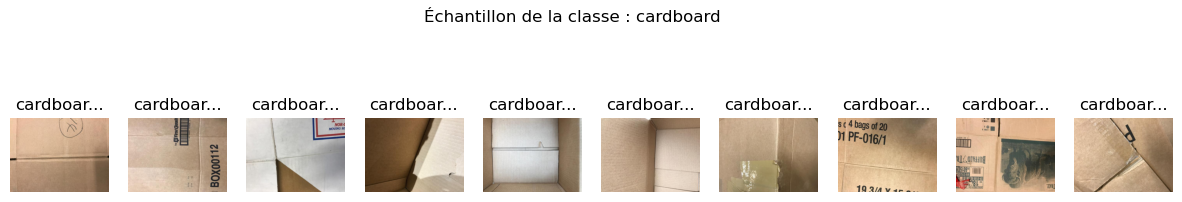

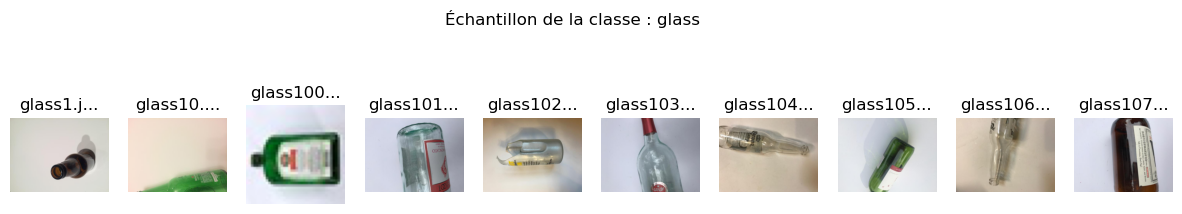

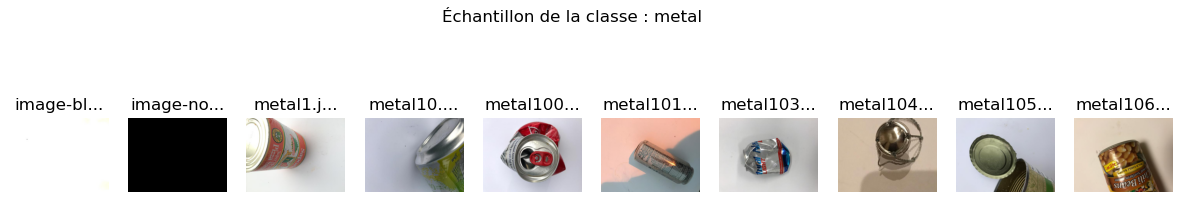

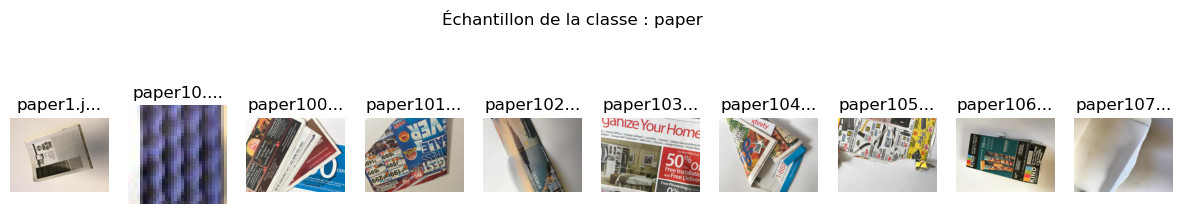

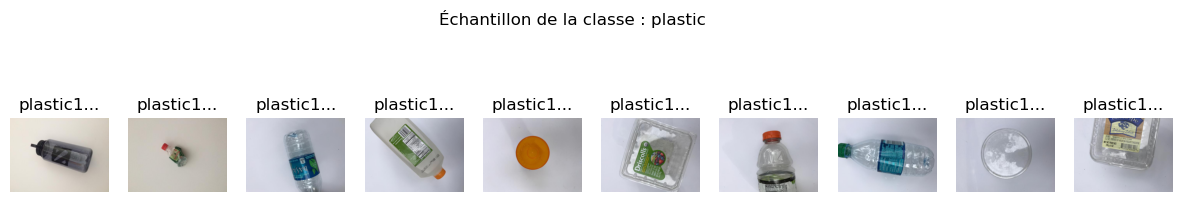

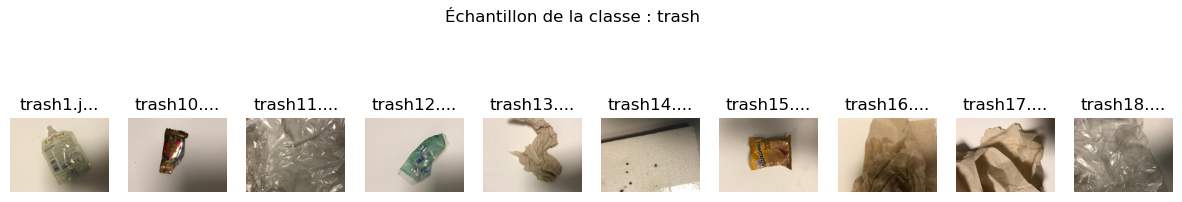

In [9]:
def plot_category_samples(df, category, samples=10):
    subset = df[(df['class'] == category) & (~df['is_corrupted'])].head(samples)
    plt.figure(figsize=(15, 3))
    for idx, (_, row) in enumerate(subset.iterrows()):
        plt.subplot(1, samples, idx + 1)
        img = Image.open(row['file_path'])
        plt.imshow(img)
        plt.title(f"{row['file_name'][:8]}...")
        plt.axis('off')
    plt.suptitle(f"Échantillon de la classe : {category}")
    plt.show()

# Affichage pour chaque classe
for c in CLASSES:
    plot_category_samples(df_meta, c)

# Exemple : marquage manuel si une image 'metal' se trouve dans 'paper'
# (Remplacez 'image_exemple.jpg' par le nom réel identifié)
df_meta['is_misclassified'] = False
# df_meta.loc[df_meta['file_name'] == 'image_erreur.jpg', 'is_misclassified'] = True

# Partie 8 : Analyser le déséquilibre des classes

Déterminer le nombre d'images par classe 

Explication : Nous comptons le nombre d'images valides par classe et traçons un histogramme.

Nombre d'images valides par classe :
class
paper        245
plastic      218
glass        182
cardboard    164
metal        139
trash         49
Name: count, dtype: int64


C:\Users\bmd\AppData\Local\Temp\ipykernel_5140\1259525515.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


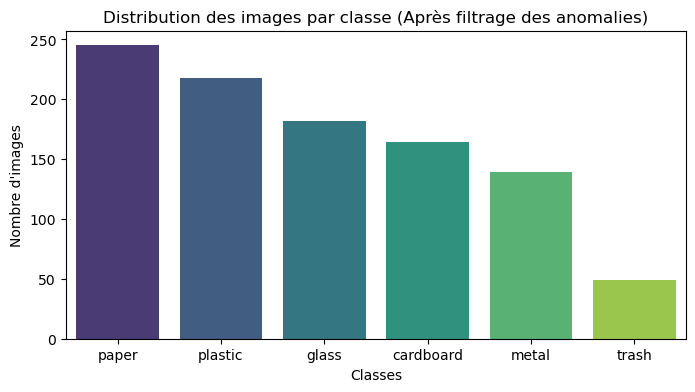

In [10]:
clean_valid_df = df_meta[
    (~df_meta['is_corrupted']) & 
    (~df_meta['is_empty']) & 
    (~df_meta['is_too_small']) & 
    (~df_meta['is_duplicate']) & 
    (~df_meta['is_misclassified'])
]

class_counts = clean_valid_df['class'].value_counts()
print("Nombre d'images valides par classe :")
print(class_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title("Distribution des images par classe (Après filtrage des anomalies)")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")
plt.show()

 Génération du Rapport d'Audit : À ce stade, nous enregistrons le rapport récapitulatif demandé dans la consigne :

In [11]:
audit_summary = {
    "total d'images": [len(df_meta)],
    "Images corrompues": [df_meta['is_corrupted'].sum()],
    "Images quasi vides": [df_meta['is_empty'].sum()],
    "Images trop petites": [df_meta['is_too_small'].sum()],
    "Doublons": [df_meta['is_duplicate'].sum()],
    "Images grayscale": [df_meta['is_grayscale'].sum()],
    "Images RGBA": [df_meta['is_rgba'].sum()],
    "images mal classées": [df_meta['is_misclassified'].sum()]
}

df_audit = pd.DataFrame(audit_summary)
df_audit.to_csv(REPORT_DIR / "audit_images.csv", index=False)
print("Rapport d'audit sauvegardé dans reports/audit_images.csv")
df_audit

Rapport d'audit sauvegardé dans reports/audit_images.csv


,total d'images,Images corrompues,Images quasi vides,Images trop petites,Doublons,Images grayscale,Images RGBA,images mal classées
0,1032,6,2,13,15,2,18,0


# Partie 9 : Redimensionnement 

Les modèles de Deep Learning (comme ResNet, MobileNet, etc.) nécessitent des images ayant toutes la même dimension (souvent $224 \times 224$ pixels).   Si on déforme simplement l'image pour forcer la taille $224 \times 224$, un objet allongé ou carré sera étiré. Pour éviter cela, on utilise le padding :L'image est redimensionnée proportionnellement pour entrer dans la case $224 \times 224$.Les espaces vides restants (en haut/bas ou à gauche/droite) sont remplis avec une couleur neutre (par exemple du noir (0, 0, 0)).

In [15]:
from PIL import Image, ImageOps

def resize_with_padding(img, target_size=(224, 224)):
    """
    Redimensionne une image PIL à target_size tout en préservant son ratio d'aspect
    en ajoutant un bord (padding) noir autour si nécessaire.
    """
    # ImageOps.pad conserve le ratio d'aspect et ajoute le padding
    img_padded = ImageOps.pad(img, target_size, color=(0, 0, 0))
    return img_padded

# --- Test de vérification sur une image du dataset ---
# Prenons la première image valide pour tester la fonction
sample_row = clean_valid_df.iloc[0]
sample_img = Image.open(sample_row['file_path'])

resized_sample = resize_with_padding(sample_img, (224, 224))

print("Dimension originale :", sample_img.size)
print("Nouvelle dimension :", resized_sample.size)

Dimension originale : (512, 384)
Nouvelle dimension : (224, 224)


# Partie 10 : Uniformisation des canaux 

Certaines images du dataset sont en niveaux de gris (1 canal L), d'autres en couleur standard (3 canaux RGB), et d'autres contiennent un canal de transparence (4 canaux RGBA).   Pour qu'un réseau de neurones reçoive des tenseurs homogènes, il faut convertir toutes les images au format RGB (3 canaux : Rouge, Vert, Bleu) :   

Une image en niveaux de gris verra son unique canal dupliqué sur 3 canaux.

Le canal de transparence (Alpha) des images RGBA sera supprimé.

In [16]:
def convert_to_rgb(img):
    """
    Convertit n'importe quel mode d'image PIL (L, RGBA, CMYK, etc.) en RGB.
    """
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

# --- Test de vérification ---
rgb_sample = convert_to_rgb(resized_sample)
print("Mode de l'image :", rgb_sample.mode)
print("Nombre de canaux :", len(rgb_sample.getbands())) # Doit afficher 3

Mode de l'image : RGB
Nombre de canaux : 3


In [18]:
from PIL import Image, ImageOps

def convert_to_rgb(img):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

def resize_with_padding(img, target_size=(224, 224)):
    return ImageOps.pad(img, target_size, color=(0, 0, 0))

# Assurer la création des sous-dossiers
for class_name in CLASSES:
    (CLEANED_DIR / class_name).mkdir(parents=True, exist_ok=True)

# Sauvegarde effective des images
for idx, row in clean_valid_df.iterrows():
    src_path = Path(row['file_path'])
    dest_path = CLEANED_DIR / row['class'] / row['file_name']
    
    with Image.open(src_path) as img:
        img_rgb = convert_to_rgb(img)
        img_final = resize_with_padding(img_rgb, (224, 224))
        img_final.save(dest_path)

print("Sauvegarde terminée !")

Sauvegarde terminée !


# Partie 11 : Mise à l'échelle des pixels 

Normaliser les valeurs des pixels de toutes les images. 

Les valeurs des pixels d'une image sont des entiers compris entre 0 et 255.En Deep Learning, il est préférable de ramener ces valeurs dans un intervalle plus petit, généralement $[0.0, 1.0]$ (ou $[-1.0, 1.0]$) :

Cela accélère la convergence lors de l'entraînement avec la descente de gradient.

Cela empêche les valeurs élevées de créer des gradients instables.On effectue généralement cette étape lors du chargement des images sous forme de tableaux NumPy ou de tenseurs TensorFlow/PyTorch.

In [19]:
import numpy as np
from PIL import Image

def normalize_image(img_pil):
    img_array = np.array(img_pil, dtype=np.float32)
    normalized_array = img_array / 255.0
    return normalized_array

# --- Test de vérification sécurisé ---
cleaned_files = list(CLEANED_DIR.glob("*/*"))

if len(cleaned_files) == 0:
    print("⚠️ Aucune image trouvée dans data/cleaned/. Veuillez exécuter la boucle de sauvegarde ci-dessus.")
else:
    sample_cleaned_path = cleaned_files[0]
    sample_cleaned_img = Image.open(sample_cleaned_path)

    # Normalisation
    normalized_img = normalize_image(sample_cleaned_img)

    print("Image chargée depuis :", sample_cleaned_path)
    print("Forme du tableau (Shape) :", normalized_img.shape)
    print("Valeur min des pixels :", normalized_img.min())
    print("Valeur max des pixels :", normalized_img.max())

Image chargée depuis : ..\data\cleaned\cardboard\cardboard1.jpg
Forme du tableau (Shape) : (224, 224, 3)
Valeur min des pixels : 0.0
Valeur max des pixels : 1.0


# Partie 12 : Découpage Train/Validation/Test 

Découper le dataset nettoyé (cleaned) en trois sous-ensembles : train, validation et test 

In [20]:
cleaned_filepaths = []
cleaned_labels = []

for class_name in CLASSES:
    for p in (CLEANED_DIR / class_name).glob("*"):
        if p.is_file():
            cleaned_filepaths.append(str(p))
            cleaned_labels.append(class_name)

df_cleaned_all = pd.DataFrame({'path': cleaned_filepaths, 'label': cleaned_labels})

# Découpage Stratifié : Train (70%), Temp (30%)
train_df, temp_df = train_test_split(
    df_cleaned_all, test_size=0.30, random_state=42, stratify=df_cleaned_all['label']
)

# Découpage de Temp : Validation (15%), Test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

print(f"Train set : {len(train_df)} images")
print(f"Validation set : {len(val_df)} images")
print(f"Test set : {len(test_df)} images")

Train set : 697 images
Validation set : 150 images
Test set : 150 images
